# Decision Trees in Classification & Regression Tasks

## Classification

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=4, cluster_std=1.5, random_state=11)


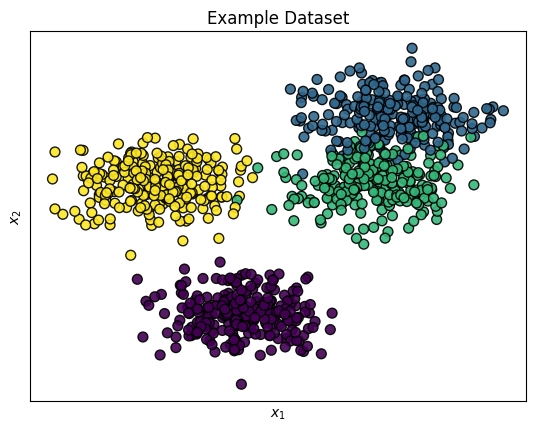

In [3]:
import matplotlib.pyplot as plt

def plot_data(X, y, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, alpha=0.9, edgecolor='black')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_xticks([])
    ax.set_yticks([])

plot_data(X, y)
plt.title('Example Dataset')
plt.show()

## Data Preparation

Split the dataset into a 80/20 training and test set:

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=622)

## Regularization Hyperparameters

**DecisionTreeClassifier** has several hyperparameters which control the tree structure and prevent overfitting:
- **max_depth**: the maximum depth of the tree,
- **min_samples_split**: the minimum number of samples required to split an internal node,
- **min_samples_leaf**: the minimum number of samples required to be at a leaf node,
- **max_features**: the number of features to consider when looking for the best split.

These regularization parameters help prevent overfitting by constraining tree growth.

### Impact of max_depth on Model Complexity


We'll train three decision tree models with different max_depth values to observe how this hyperparameter affects model complexity and decision boundaries:

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_clf_md_1 = DecisionTreeClassifier(max_depth=2, random_state=622)

tree_clf_md_2 = DecisionTreeClassifier(max_depth=4, random_state=622)

tree_clf_md_3 = DecisionTreeClassifier(max_depth=None, random_state=622)

tree_clf_md_1.fit(X_train, y_train)
tree_clf_md_2.fit(X_train, y_train)
tree_clf_md_3.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",622
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

#### Tree Structure Visualization

Below is the decision tree structure with **max_depth = 4** (moderate complexity):

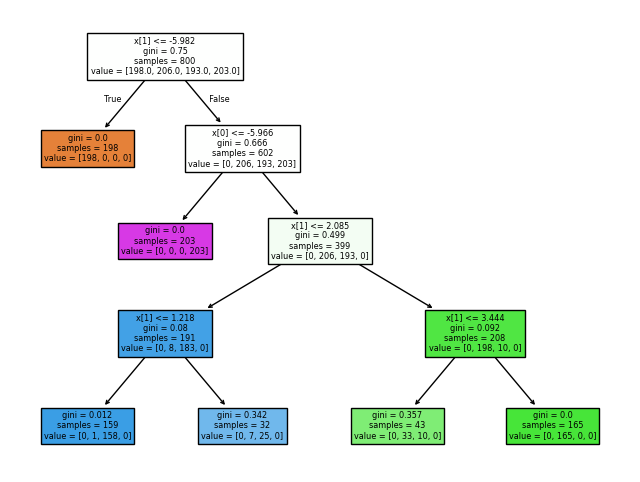

In [6]:
plt.figure(figsize=(8, 6))
plot_tree(tree_clf_md_2, filled=True, impurity=True)
plt.show()

With no depth restriction, the tree becomes much deeper and more complex (may lead to overfitting):

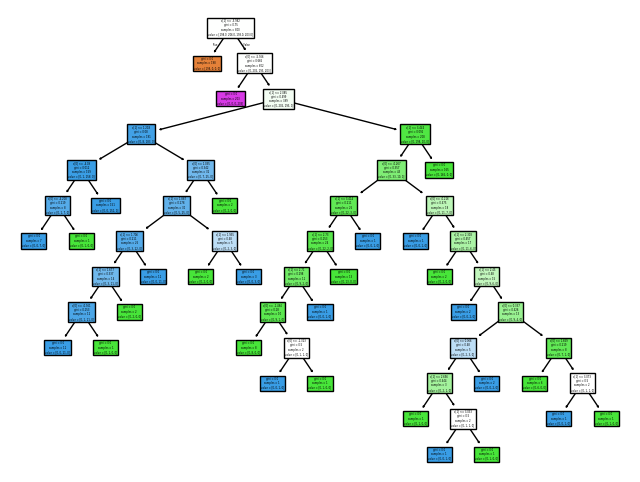

In [7]:
plt.figure(figsize=(8, 6))
plot_tree(tree_clf_md_3, filled=True, impurity=True)
plt.show()

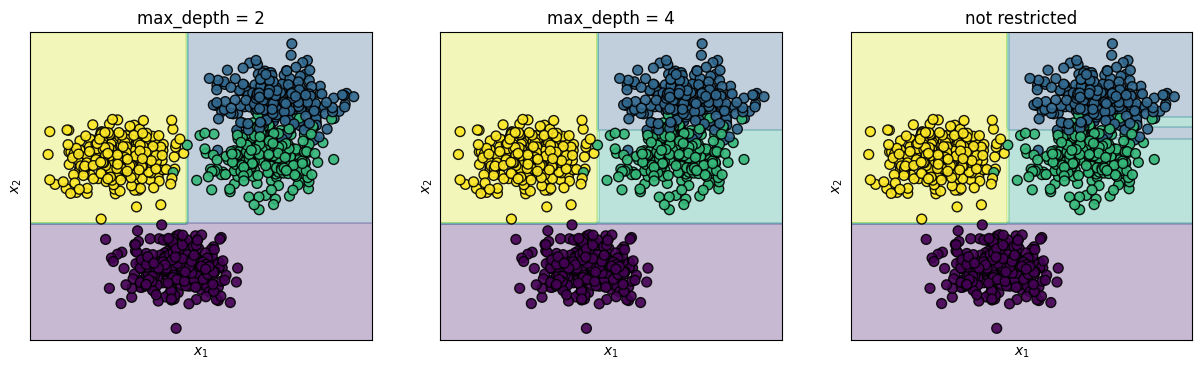

In [8]:
from sklearn.inspection import DecisionBoundaryDisplay

titles = ['max_depth = 2',
          'max_depth = 4',
          'not restricted']

models = [tree_clf_md_1, tree_clf_md_2, tree_clf_md_3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for model, title, ax in zip(models, titles, axes.flatten()):

    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method='predict',
        alpha=0.3,
        ax= ax,
    )
    ax.set_title(title)
    plot_data(X, y, ax)

plt.show()

#### Decision Boundaries Comparison

The visualization above shows how different max_depth values create different decision boundaries. Notice how:
- **max_depth=2**: leads to underfitting
- **max_depth=4**: is balanced  
- **Unrestricted**: leads to overfitting

## Hyperparameter Tuning with RandomizedSearchCV

**RandomizedSearchCV** performs random search with cross-validation over specified parameter distributions. It helps find the optimal combination of hyperparameters without exhaustively trying all possibilities.

In [9]:
dt_model = DecisionTreeClassifier()

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

params = {
    'max_leaf_nodes': randint(low = 2, high = 100),
    'max_depth': randint(low = 2, high = 10),
    'min_samples_split': randint(low = 2, high = 18),

}

dt_search = RandomizedSearchCV(estimator=dt_model,
                               param_distributions=params,
                               n_iter=100, 
                               cv=5, 
                               random_state=622)

dt_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....005A7ADD19110>, 'max_leaf_nodes': <scipy.stats....005A7AC4BFD90>, 'min_samples_split': <scipy.stats....005A7ADD19390>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

### Best Parameters Found

The search performed 100 iterations of random parameter combinations with 5-fold cross-validation. Here are the optimal hyperparameters:

In [11]:
dt_search.best_params_

{'max_depth': 3, 'max_leaf_nodes': 25, 'min_samples_split': 2}

### Extracting the Best Model and Evaluating Performance

Extract the best model from the search results and evaluate it on the test set:


In [12]:
best_dt_model = dt_search.best_estimator_

In [13]:
best_dt_model.score(X_test, y_test)

0.965

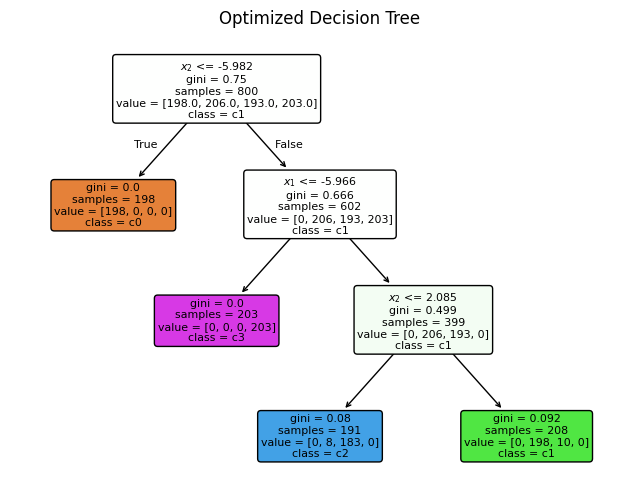

In [14]:
plt.figure(figsize=(8, 6))
plot_tree(best_dt_model,
          filled=True,
          feature_names=['$x_1$', '$x_2$'],
          class_names=['c0', 'c1', 'c2', 'c3'],
          rounded=True)
plt.title('Optimized Decision Tree')
plt.show()

## Confusion Matrix

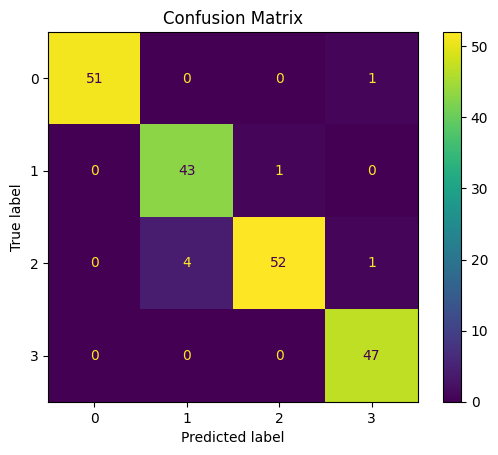

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_dt_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

---

## Regression

### Data Generation

For regression, we'll use a cosine function with added noise: $y = \cos(2x) + \text{noise}$


This simple dataset allows us to observe how decision trees with different minimum number of samples at a leaf node  fit continuous data:
- **min_samples_leaf=8**: Simpler model with fewer decision boundaries, may underfit
- **min_samples_leaf=1**: More complex model with more boundaries, better fit, but may overfit


In [32]:
import numpy as np

m = 300
np.random.seed(622)

X = np.random.uniform(low = 0, high= 10, size= m)

y =  np.cos(2* X) + np.random.uniform(low= -0.5, high= 0.5, size= m)

m = 300
np.random.seed(622)

X = np.random.uniform(low = 0, high= 10, size= m)

y =  np.cos(2* X) + np.random.uniform(low= -0.5, high= 0.5, size= m)

y= y.reshape(-1, 1)
X= X.reshape(-1, 1)




### Training Decision Tree Regressors

We'll train two **DecisionTreeRegressor** models with different min_samples_leaf values to compare how tree complexity affects the fit on our regression data. Unlike classification which predicts discrete classes, regression predicts continuous values.

In [55]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(random_state=622)

tree_reg2 = DecisionTreeRegressor(min_samples_leaf=8, random_state=622)

tree_reg1.fit(X, y)

tree_reg2.fit(X, y)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",622
,"max_

### Tree Structure Visualization

Below are the decision tree structures for our two regressor models.

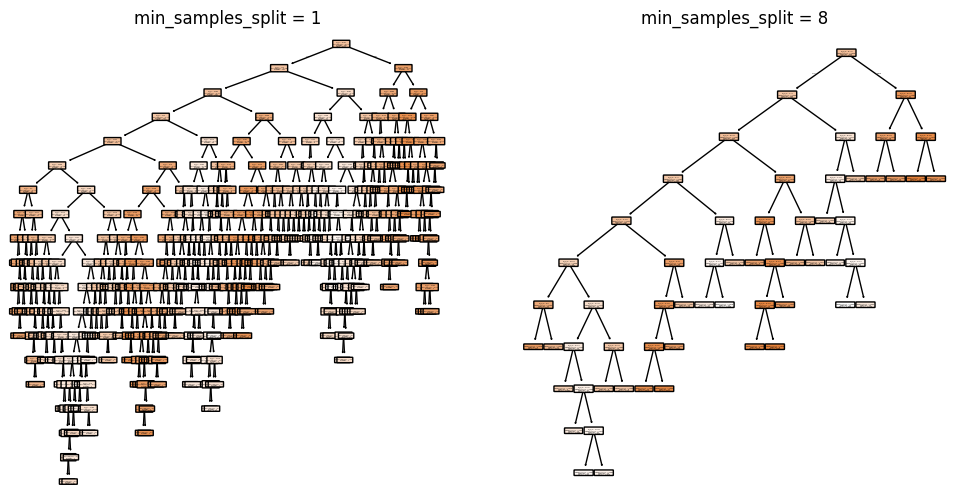

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_tree(tree_reg1,
          rounded=True,
          ax= axes[0],
          filled=True)
axes[0].set_title(f'min_samples_leaf = {tree_reg1.min_samples_leaf}')
plot_tree(tree_reg2,
          rounded=True,
          ax= axes[1],
          filled=True)
axes[1].set_title(f'min_samples_leaf = {tree_reg2.min_samples_leaf}')
plt.show()

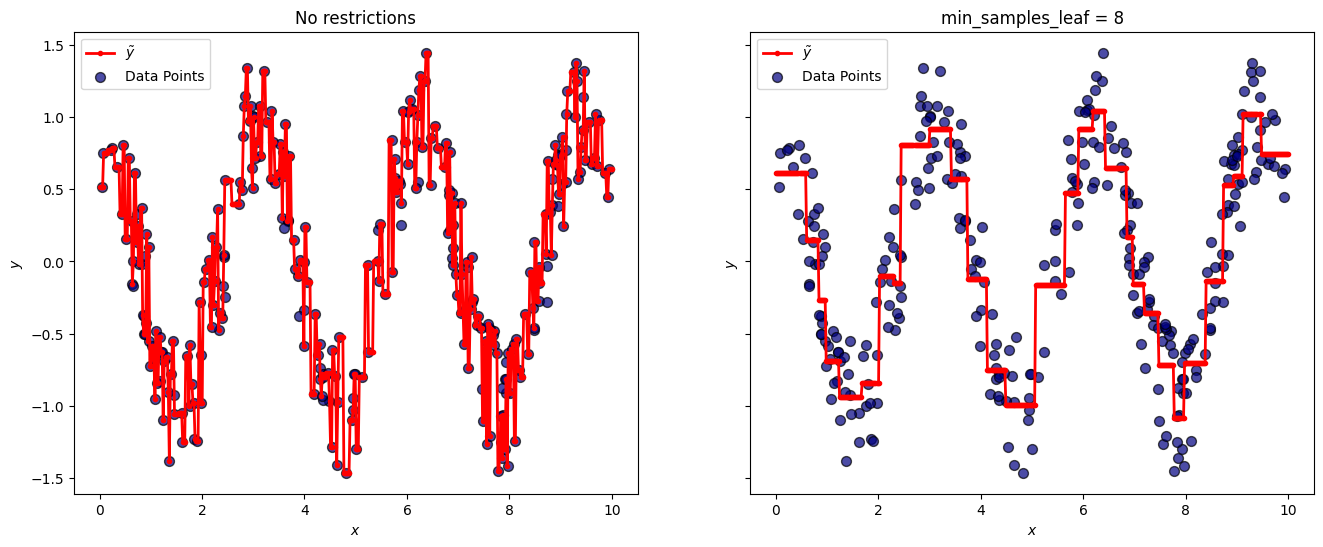

In [66]:
x_p =  np.linspace(0, 10, 500).reshape(-1, 1)

y_pred1 = tree_reg1.predict(x_p)
y_pred2 = tree_reg2.predict(x_p)

fig, axes = plt.subplots(ncols=2, figsize=(16, 6), sharey=True)

plt.sca(axes[0])
plt.plot(x_p, y_pred1, 'r.-', linewidth=2, label = r'$\tilde{y}$')
plt.scatter(X, y, color='navy', label='Data Points', edgecolor='black', alpha=0.7, s=50)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('No restrictions')
plt.legend()


plt.sca(axes[1])
plt.plot(x_p, y_pred2, 'r.-', linewidth=2, label = r'$\tilde{y}$')
plt.scatter(X, y, color='navy', label='Data Points', edgecolor='black', alpha=0.7, s=50)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'min_samples_leaf = {tree_reg2.min_samples_leaf}')
plt.legend()

plt.show()

### Regression Predictions Comparison

The plots below compare the predicted regression lines from the two models against the original data:

- **Left plot (No restrictions)**: Shows the unrestricted tree's predictions. It creates a step-like function that fits the training data very closely, potentially overfitting and capturing noise in the data.
- **Right plot (min_samples_leaf = 8)**: Shows the regularized tree's predictions. By requiring at least 8 samples per leaf node, the model is forced to create smoother, less complex decision boundaries. This reduces overfitting while maintaining a reasonable fit to the underlying cosine pattern.

The red line represents the model's predictions ($\tilde{y}$), while the navy scatter points show the original training data. Notice how the regularized model on the right produces a smoother curve that better represents the underlying trend, whereas the unrestricted model creates many small segments that may not generalize well to new data.